In [1]:
import pandas as pd

In [2]:
def load_data():
    try :
        df = pd.read_csv("sys_data.csv")
        return df
    except FileNotFoundError :
        print("Make sure you have file in this directory")
        return None
    except Exception as e :
        print(f"Error : {str(e)}")
        return None
df = load_data()

In [3]:
df.head()

,timestamp,cpu_usage,memory_usage,disk_usage
0,2026-01-15 15:50:01,4.9,28.3,39.5
1,2026-01-15 15:51:01,3.0,28.5,39.5
2,2026-01-15 15:52:01,5.8,28.4,39.5
3,2026-01-15 15:53:01,30.7,30.3,39.5
4,2026-01-15 15:54:01,5.8,27.7,39.5


In [4]:
df.tail()

,timestamp,cpu_usage,memory_usage,disk_usage
489,2026-01-17 15:29:01,4.0,59.4,42.7
490,2026-01-17 15:30:01,14.7,59.3,42.7
491,2026-01-17 15:31:01,10.1,59.4,42.7
492,2026-01-17 15:32:01,18.2,59.4,42.7
493,2026-01-17 15:33:01,6.8,59.9,42.7


In [5]:
df.isnull().sum()

timestamp       0
cpu_usage       0
memory_usage    0
disk_usage      0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 494 entries, 0 to 493
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   timestamp     494 non-null    object 
 1   cpu_usage     494 non-null    float64
 2   memory_usage  494 non-null    float64
 3   disk_usage    494 non-null    float64
dtypes: float64(3), object(1)
memory usage: 15.6+ KB


In [8]:
df.shape

(494, 4)

In [9]:
df.columns

Index(['timestamp', 'cpu_usage', 'memory_usage', 'disk_usage'], dtype='object')

In [10]:
df.describe()

,cpu_usage,memory_usage,disk_usage
count,494.000000,494.000000,494.000000
mean,10.579150,40.052024,41.654049
std,11.400651,14.762005,1.426301
min,0.300000,9.200000,39.500000
25%,3.000000,27.400000,39.500000
50%,6.750000,43.350000,42.600000
75%,13.800000,54.000000,42.700000
max,98.300000,68.600000,44.100000


In [11]:
df["timestamp"].dtype

dtype('O')

In [12]:
df["timestamp"] = pd.to_datetime(df["timestamp"], errors = "coerce")

In [13]:
df["timestamp"].dtype

dtype('<M8[ns]')

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 494 entries, 0 to 493
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   timestamp     494 non-null    datetime64[ns]
 1   cpu_usage     494 non-null    float64       
 2   memory_usage  494 non-null    float64       
 3   disk_usage    494 non-null    float64       
dtypes: datetime64[ns](1), float64(3)
memory usage: 15.6 KB


In [15]:
df.columns

Index(['timestamp', 'cpu_usage', 'memory_usage', 'disk_usage'], dtype='object')

In [16]:
def create_time_feature(df):
    df["year"] = df["timestamp"].dt.year
    df["month"] = df["timestamp"].dt.month
    df["day"] = df["timestamp"].dt.day
    df["hour"] = df["timestamp"].dt.hour
    df["minute"] = df["timestamp"].dt.minute
    df["day_of_week"] = df["timestamp"].dt.day_name()
    df["month_name"] = df["timestamp"].dt.month_name()
    df["day_of_year"] = df["timestamp"].dt.dayofyear
    return df

df = create_time_feature(df)

In [17]:
df.columns

Index(['timestamp', 'cpu_usage', 'memory_usage', 'disk_usage', 'year', 'month',
       'day', 'hour', 'minute', 'day_of_week', 'month_name', 'day_of_year'],
      dtype='object')

In [18]:
df.head()

,timestamp,cpu_usage,memory_usage,disk_usage,year,month,day,hour,minute,day_of_week,month_name,day_of_year
0,2026-01-15 15:50:01,4.9,28.3,39.5,2026,1,15,15,50,Thursday,January,15
1,2026-01-15 15:51:01,3.0,28.5,39.5,2026,1,15,15,51,Thursday,January,15
2,2026-01-15 15:52:01,5.8,28.4,39.5,2026,1,15,15,52,Thursday,January,15
3,2026-01-15 15:53:01,30.7,30.3,39.5,2026,1,15,15,53,Thursday,January,15
4,2026-01-15 15:54:01,5.8,27.7,39.5,2026,1,15,15,54,Thursday,January,15


In [19]:
df.tail()

,timestamp,cpu_usage,memory_usage,disk_usage,year,month,day,hour,minute,day_of_week,month_name,day_of_year
489,2026-01-17 15:29:01,4.0,59.4,42.7,2026,1,17,15,29,Saturday,January,17
490,2026-01-17 15:30:01,14.7,59.3,42.7,2026,1,17,15,30,Saturday,January,17
491,2026-01-17 15:31:01,10.1,59.4,42.7,2026,1,17,15,31,Saturday,January,17
492,2026-01-17 15:32:01,18.2,59.4,42.7,2026,1,17,15,32,Saturday,January,17
493,2026-01-17 15:33:01,6.8,59.9,42.7,2026,1,17,15,33,Saturday,January,17


In [20]:
df.describe()

,timestamp,cpu_usage,memory_usage,disk_usage,year,month,day,hour,minute,day_of_year
count,494,494.000000,494.000000,494.000000,494.0,494.0,494.000000,494.000000,494.000000,494.000000
mean,2026-01-16 11:35:14.153846016,10.579150,40.052024,41.654049,2026.0,1.0,15.751012,17.064777,29.870445,15.751012
min,2026-01-15 15:50:01,0.300000,9.200000,39.500000,2026.0,1.0,15.000000,14.000000,0.000000,15.000000
25%,2026-01-15 18:16:16,3.000000,27.400000,39.500000,2026.0,1.0,15.000000,15.000000,15.000000,15.000000
50%,2026-01-16 15:17:31,6.750000,43.350000,42.600000,2026.0,1.0,16.000000,16.000000,31.000000,16.000000
75%,2026-01-16 21:39:46,13.800000,54.000000,42.700000,2026.0,1.0,16.000000,19.000000,44.000000,16.000000
max,2026-01-17 15:33:01,98.300000,68.600000,44.100000,2026.0,1.0,17.000000,22.000000,59.000000,17.000000
std,NaN,11.400651,14.762005,1.426301,0.0,0.0,0.677626,2.584054,17.128775,0.677626


In [21]:
df['timestamp'].min(), df['timestamp'].max()

(Timestamp('2026-01-15 15:50:01'), Timestamp('2026-01-17 15:33:01'))

In [22]:
df.corr(numeric_only=True)

,cpu_usage,memory_usage,disk_usage,year,month,day,hour,minute,day_of_year
cpu_usage,1.000000,0.092977,0.035892,NaN,NaN,-0.020628,0.003681,0.057291,-0.020628
memory_usage,0.092977,1.000000,0.136299,NaN,NaN,0.355589,-0.544737,0.003789,0.355589
disk_usage,0.035892,0.136299,1.000000,NaN,NaN,0.746820,0.021723,-0.069065,0.746820
year,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
month,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day,-0.020628,0.355589,0.746820,NaN,NaN,1.000000,-0.319758,0.004380,1.000000
hour,0.003681,-0.544737,0.021723,NaN,NaN,-0.319758,1.000000,-0.161672,-0.319758
minute,0.057291,0.003789,-0.069065,NaN,NaN,0.004380,-0.161672,1.000000,0.004380
day_of_year,-0.020628,0.355589,0.746820,NaN,NaN,1.000000,-0.319758,0.004380,1.000000


In [23]:
df_numeric = df.select_dtypes(include=['int64', 'float64'])

In [24]:
df_numeric

,cpu_usage,memory_usage,disk_usage
0,4.9,28.3,39.5
1,3.0,28.5,39.5
2,5.8,28.4,39.5
3,30.7,30.3,39.5
4,5.8,27.7,39.5
...,...,...,...
489,4.0,59.4,42.7
490,14.7,59.3,42.7
491,10.1,59.4,42.7
492,18.2,59.4,42.7


In [25]:
corr = df_numeric.corr()
corr

,cpu_usage,memory_usage,disk_usage
cpu_usage,1.000000,0.092977,0.035892
memory_usage,0.092977,1.000000,0.136299
disk_usage,0.035892,0.136299,1.000000


In [26]:
df.columns

Index(['timestamp', 'cpu_usage', 'memory_usage', 'disk_usage', 'year', 'month',
       'day', 'hour', 'minute', 'day_of_week', 'month_name', 'day_of_year'],
      dtype='object')

In [27]:
df.groupby("hour")[["cpu_usage", "memory_usage", "disk_usage"]].mean()

,cpu_usage,memory_usage,disk_usage
hour,,,
14,10.475000,42.127778,42.427778
15,11.031731,52.596154,42.362500
16,8.496000,39.525000,41.224000
17,10.774510,48.966667,39.500000
18,13.444444,39.566667,39.500000
19,18.266667,36.136667,40.143333
20,12.985714,26.485714,42.411429
21,6.546809,25.082979,42.600000
22,10.089189,25.148649,42.643243


In [28]:
df.groupby("day_of_week") [["cpu_usage", "memory_usage", "disk_usage"]].mean()

,cpu_usage,memory_usage,disk_usage
day_of_week,,,
Friday,9.602110,39.741350,42.583544
Saturday,11.720896,53.688060,42.665672
Thursday,11.395263,35.631053,40.137895


In [29]:
df[df['day_of_week'] == 'Saturday'].groupby('hour')['memory_usage'].mean()

hour
14    48.739394
15    58.491176
Name: memory_usage, dtype: float64

In [30]:
df.groupby(['day_of_week','hour'])[['cpu_usage','memory_usage']].mean()


cpu_usage  memory_usage
day_of_week hour                         
Friday      14     8.556410     36.533333
            15    11.391667     53.308333
            16    10.694444     49.740741
            21     6.546809     25.082979
            22    10.089189     25.148649
Saturday    14    12.742424     48.739394
            15    10.729412     58.491176
Thursday    15     9.900000     28.280000
            16     5.915217     27.532609
            17    10.774510     48.966667
            18    13.444444     39.566667
            19    18.266667     36.136667
            20    12.985714     26.485714

In [31]:
df.groupby('day')[['memory_usage']].mean()

,memory_usage
day,
15,35.631053
16,39.741350
17,53.688060


In [32]:
df['is_weekend'] = df['timestamp'].dt.dayofweek >= 5

In [33]:
df.head()

,timestamp,cpu_usage,memory_usage,disk_usage,year,month,day,hour,minute,day_of_week,month_name,day_of_year,is_weekend
0,2026-01-15 15:50:01,4.9,28.3,39.5,2026,1,15,15,50,Thursday,January,15,False
1,2026-01-15 15:51:01,3.0,28.5,39.5,2026,1,15,15,51,Thursday,January,15,False
2,2026-01-15 15:52:01,5.8,28.4,39.5,2026,1,15,15,52,Thursday,January,15,False
3,2026-01-15 15:53:01,30.7,30.3,39.5,2026,1,15,15,53,Thursday,January,15,False
4,2026-01-15 15:54:01,5.8,27.7,39.5,2026,1,15,15,54,Thursday,January,15,False


In [34]:
df.tail()

,timestamp,cpu_usage,memory_usage,disk_usage,year,month,day,hour,minute,day_of_week,month_name,day_of_year,is_weekend
489,2026-01-17 15:29:01,4.0,59.4,42.7,2026,1,17,15,29,Saturday,January,17,True
490,2026-01-17 15:30:01,14.7,59.3,42.7,2026,1,17,15,30,Saturday,January,17,True
491,2026-01-17 15:31:01,10.1,59.4,42.7,2026,1,17,15,31,Saturday,January,17,True
492,2026-01-17 15:32:01,18.2,59.4,42.7,2026,1,17,15,32,Saturday,January,17,True
493,2026-01-17 15:33:01,6.8,59.9,42.7,2026,1,17,15,33,Saturday,January,17,True


In [35]:
df['cpu_roll_mean_5'] = df['cpu_usage'].rolling(window=5).mean()

In [36]:
df["cpu_roll_mean_5"]

0        NaN
1        NaN
2        NaN
3        NaN
4      10.04
       ...  
489     7.78
490    10.16
491     9.46
492    11.62
493    10.76
Name: cpu_roll_mean_5, Length: 494, dtype: float64

In [37]:
df['cpu_roll_std_5'] = df['cpu_usage'].rolling(window=5).std()

In [38]:
df["cpu_roll_std_5"]

0            NaN
1            NaN
2            NaN
3            NaN
4      11.605731
         ...    
489     4.586066
490     4.441058
491     4.019079
492     5.325129
493     5.759601
Name: cpu_roll_std_5, Length: 494, dtype: float64

In [39]:
df.set_index('timestamp', inplace=True)
df['cpu_roll_30min'] = df['cpu_usage'].rolling('30min').mean()

In [40]:
df["cpu_roll_30min"]

timestamp
2026-01-15 15:50:01     4.900000
2026-01-15 15:51:01     3.950000
2026-01-15 15:52:01     4.566667
2026-01-15 15:53:01    11.100000
2026-01-15 15:54:01    10.040000
                         ...    
2026-01-17 15:29:01    10.500000
2026-01-17 15:30:01    10.526667
2026-01-17 15:31:01    10.550000
2026-01-17 15:32:01    10.796774
2026-01-17 15:33:01    10.236667
Name: cpu_roll_30min, Length: 494, dtype: float64

In [41]:
df.columns

Index(['cpu_usage', 'memory_usage', 'disk_usage', 'year', 'month', 'day',
       'hour', 'minute', 'day_of_week', 'month_name', 'day_of_year',
       'is_weekend', 'cpu_roll_mean_5', 'cpu_roll_std_5', 'cpu_roll_30min'],
      dtype='object')

In [42]:
df.head()

,cpu_usage,memory_usage,disk_usage,year,month,day,hour,minute,day_of_week,month_name,day_of_year,is_weekend,cpu_roll_mean_5,cpu_roll_std_5,cpu_roll_30min
timestamp,,,,,,,,,,,,,,,
2026-01-15 15:50:01,4.9,28.3,39.5,2026,1,15,15,50,Thursday,January,15,False,NaN,NaN,4.900000
2026-01-15 15:51:01,3.0,28.5,39.5,2026,1,15,15,51,Thursday,January,15,False,NaN,NaN,3.950000
2026-01-15 15:52:01,5.8,28.4,39.5,2026,1,15,15,52,Thursday,January,15,False,NaN,NaN,4.566667
2026-01-15 15:53:01,30.7,30.3,39.5,2026,1,15,15,53,Thursday,January,15,False,NaN,NaN,11.100000
2026-01-15 15:54:01,5.8,27.7,39.5,2026,1,15,15,54,Thursday,January,15,False,10.04,11.605731,10.040000


In [43]:
df.columns

Index(['cpu_usage', 'memory_usage', 'disk_usage', 'year', 'month', 'day',
       'hour', 'minute', 'day_of_week', 'month_name', 'day_of_year',
       'is_weekend', 'cpu_roll_mean_5', 'cpu_roll_std_5', 'cpu_roll_30min'],
      dtype='object')

In [44]:
df = df.drop(columns = ["year", "month", "day", "day_of_week", "month_name", "day_of_year"])

In [45]:
df.head()

,cpu_usage,memory_usage,disk_usage,hour,minute,is_weekend,cpu_roll_mean_5,cpu_roll_std_5,cpu_roll_30min
timestamp,,,,,,,,,
2026-01-15 15:50:01,4.9,28.3,39.5,15,50,False,NaN,NaN,4.900000
2026-01-15 15:51:01,3.0,28.5,39.5,15,51,False,NaN,NaN,3.950000
2026-01-15 15:52:01,5.8,28.4,39.5,15,52,False,NaN,NaN,4.566667
2026-01-15 15:53:01,30.7,30.3,39.5,15,53,False,NaN,NaN,11.100000
2026-01-15 15:54:01,5.8,27.7,39.5,15,54,False,10.04,11.605731,10.040000


In [46]:
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 6.8 MB/s  0:00:017.4 MB/s eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 15.3 MB/s  0:00:000.7 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 32.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 17.9 MB/s  0:00:00 22.3 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib] 6/7 [matplotlib]ow]


In [48]:
import matplotlib.pyplot as plt

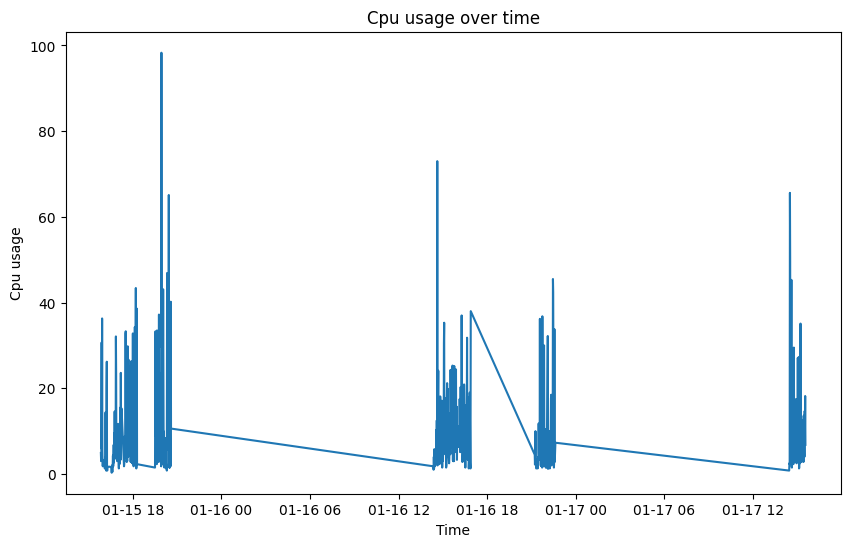

In [55]:
#plot cpu usage over time 
plt.figure(figsize = (10,6))
plt.plot(df.index, df["cpu_usage"], label = "Cpu usage")
plt.xlabel("Time")
plt.ylabel("Cpu usage")
plt.title("Cpu usage over time")
plt.savefig("Cpu_usage_over_time_plot.png", dpi=300)
plt.show()

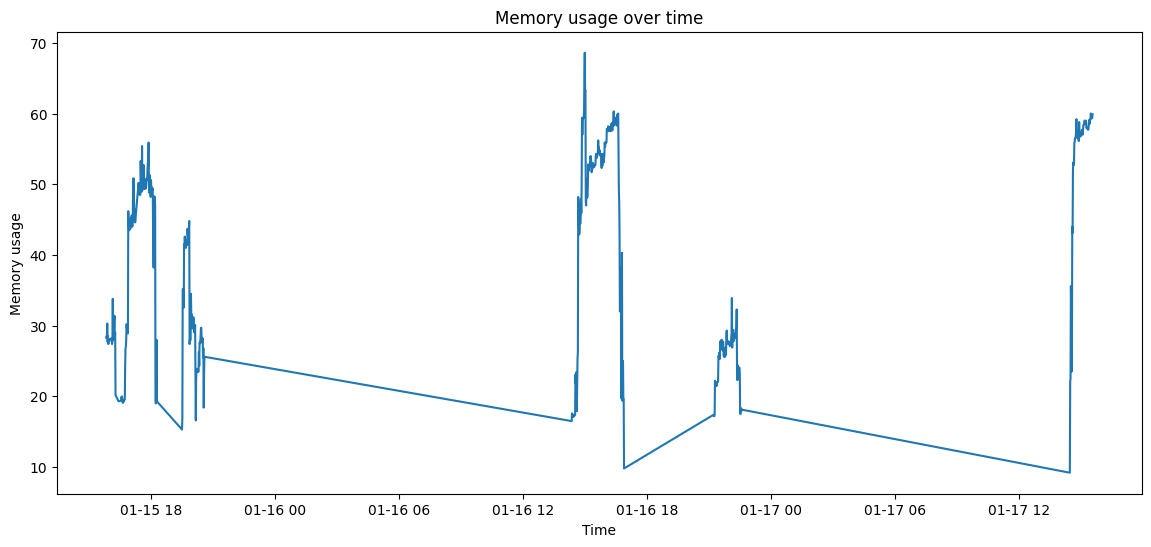

In [61]:
#plot memory usage overtime

plt.figure(figsize = (14,6))
plt.plot(df.index, df["memory_usage"], label = "Memory usage")
plt.xlabel("Time")
plt.ylabel("Memory usage")
plt.title("Memory usage over time")
plt.savefig("Memory_usage_over_time_plot.png")
plt.show()

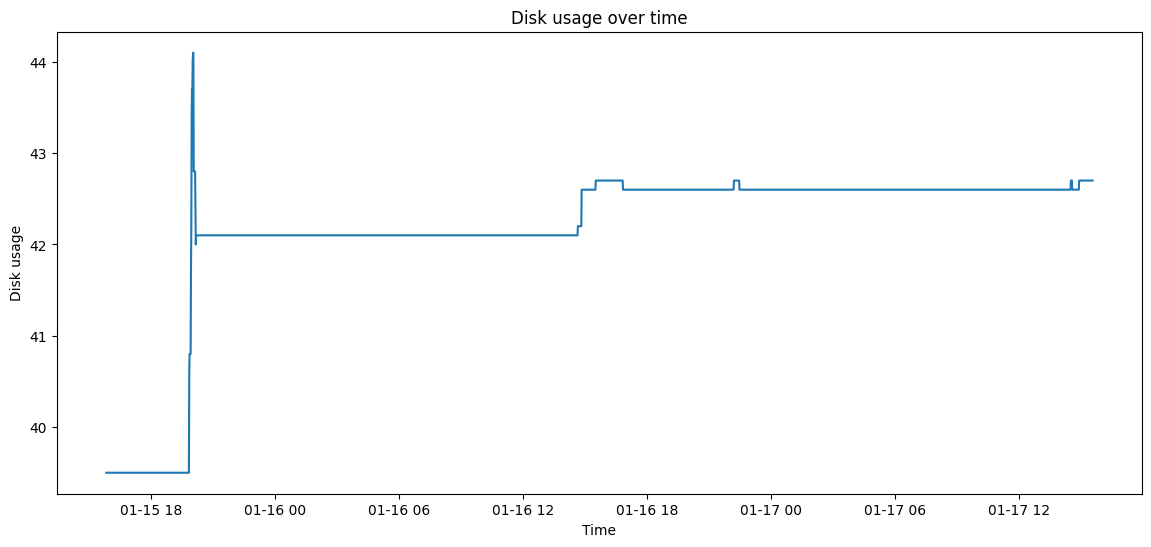

In [62]:
#plot disk usage over time 
plt.figure(figsize = (14,6))
plt.plot(df.index, df["disk_usage"], label= "Disk usage")
plt.xlabel("Time")
plt.ylabel("Disk usage")
plt.title("Disk usage over time")
plt.savefig("disk_usage_over_time_plot.png")
plt.show()

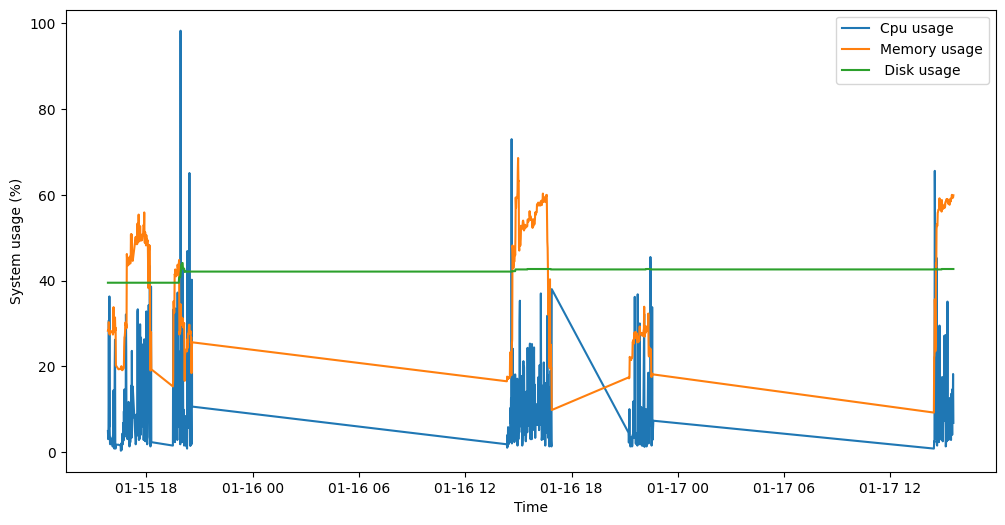

In [63]:
# plot system usage over time 
plt.figure(figsize = (12,6))
plt.plot(df.index, df["cpu_usage"], label = "Cpu usage")
plt.plot(df.index, df["memory_usage"], label = "Memory usage")
plt.plot(df.index, df["disk_usage"], label = " Disk usage")
plt.xlabel("Time")
plt.ylabel("System usage (%)")
plt.legend()
plt.savefig("system_usage_over_time_plot.png", dpi = 300)
plt.show()